# Proyek Pertama Predictive Analytics: Prediksi Biaya Asuransi Medis (Medical Cost Prediction)
- **Nama:** Krisna Rhesa
- **Dataset:** Medical Cost Personal Datasets (Kaggle)
- **Domain:** Kesehatan & Finansial (Healthcare & Financial Economics)
---

## 1. Domain Proyek

### 1.1 Latar Belakang
Biaya pengobatan dan perawatan kesehatan merupakan salah satu pengeluaran tak terduga yang paling dikhawatirkan oleh banyak orang. Menurut laporan dari *World Health Organization* (WHO, 2021), beban ekonomi dari penyakit tidak menular seperti komplikasi jantung dan diabetes terus naik di berbagai negara, di mana salah satu pemicu utamanya adalah gaya hidup yang berisiko, seperti kebiasaan merokok dan indeks massa tubuh (BMI) yang berlebih.

Di industri asuransi kesehatan, menentukan besaran premi tahunan yang pas bagi setiap nasabah adalah tantangan utama. Jika perusahaan asuransi memasang tarif terlalu rendah (*underpricing*), perusahaan terancam mengalami kerugian besar saat nasabah mengajukan klaim medis yang mahal. Sebaliknya, jika premi dipatok terlalu mahal (*overpricing*), orang-orang yang sehat akan memilih untuk tidak ikut asuransi, sehingga yang tersisa mayoritas adalah nasabah yang memang rentan sakit (*adverse selection*) sebagaimana diuraikan oleh Lantz (2019).

Masalahnya, faktor risiko kesehatan tidak bekerja secara linier sederhana. Misalnya, merokok memang menaikkan risiko kesehatan, tetapi dampaknya bisa berlipat ganda jika individu tersebut juga mengalami obesitas. Tabel premi konvensional sering kali kesulitan menangkap pola interaksi yang kompleks seperti ini.

Riset yang dilakukan oleh Ganesan et al. (2020) membuktikan bahwa pemanfaatan algoritma machine learning berbasis regresi mampu memodelkan pola non-linier dan interaksi antar variabel kesehatan tersebut secara efektif untuk memprediksi pengeluaran medis nasabah. Oleh karena itu, pada proyek ini diimplementasikan pendekatan *predictive analytics* regresi untuk mengestimasi besaran biaya tagihan medis (*charges*). Model dilatih menggunakan data karakteristik individu seperti usia, jenis kelamin, BMI, jumlah anak, kebiasaan merokok, dan wilayah domisili, agar penetapan premi dapat dilakukan secara objektif, akurat, dan adil.

### Referensi
- Ganesan, N., et al. (2020). "Application of Machine Learning Techniques in Medical Insurance Cost Prediction." *International Journal of Advanced Science and Technology*, 29(5), pp. 11452-11461.
- Lantz, B. (2019). *Machine Learning with R: Expert techniques for predictive modeling to solve problems in a practical way* (3rd ed.). Birmingham: Packt Publishing Ltd.
- World Health Organization (WHO). (2021). *Tobacco and noncommunicable diseases: Economic and health consequences of tobacco use*. Geneva: World Health Organization Press.


## 2. Business Understanding

### 2.1 Problem Statements
1. Faktor apa saja dari karakteristik diri dan gaya hidup nasabah yang paling berpengaruh terhadap besaran biaya tagihan medis (*charges*)?
2. Bagaimana tahapan penyiapan data (*data preparation*) dan pelatihan model regresi yang tepat agar model tidak mengalami kebocoran data (*data leakage*) dan menghasilkan prediksi yang akurat?
3. Dari algoritma K-Nearest Neighbors (KNN), Random Forest, dan Gradient Boosting, manakah model yang memberikan performa terbaik dan paling konsisten saat diuji dengan data baru?

### 2.2 Goals
1. Menemukan dan menganalisis faktor penentu tingginya biaya medis melalui proses *Exploratory Data Analysis* (EDA) serta melihat tingkat kepentingan fitur (*feature importance*).
2. Menyusun tahapan pemrosesan data yang terstruktur, mulai dari pembersihan data duplikat, encoding fitur teks, pemisahan data train-test, hingga standarisasi fitur numerik dengan benar.
3. Membangun dan membandingkan performa model baseline, lalu melakukan *tuning hyperparameter* pada model terbaik agar menghasilkan nilai kesalahan (RMSE) sekecil mungkin dan skor $R^2$ di atas 0.85 (85%).

### 2.3 Solution Statements
1. **Menerapkan 3 algoritma regresi yang berbeda karakteristiknya:** K-Nearest Neighbors (KNN), Random Forest Regressor, dan Gradient Boosting Regressor.
2. **Melakukan perbaikan model dengan hyperparameter tuning:** Mengoptimasi model terbaik menggunakan *GridSearchCV* dengan 5-fold cross-validation.
3. **Mengukur kinerja dengan metrik evaluasi yang jelas:** Menilai performa model secara kuantitatif menggunakan MSE, RMSE, MAE, dan $R^2$ Score pada data latih maupun data uji.

## 3. Import Libraries

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11})

## 4. Data Loading

Dataset yang digunakan adalah **Medical Cost Personal Datasets** (`insurance.csv`) yang diunduh dari repositori publik Kaggle: [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance).

In [2]:
import kagglehub

path = kagglehub.dataset_download("mirichoi0218/insurance")
data_path = os.path.join(path, "insurance.csv") if os.path.exists(os.path.join(path, "insurance.csv")) else "insurance.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1338 rows, 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 5. Exploratory Data Analysis (EDA)

### 5.1 Deskripsi Variabel
- **age**: Usia pemegang polis asuransi (numerik integer, rentang 18 - 64 tahun).
- **sex**: Jenis kelamin nasabah (`male`, `female`).
- **bmi**: *Body Mass Index* ($kg/m^2$), rasio berat badan terhadap kuadrat tinggi badan. Indeks ideal adalah 18.5 hingga 24.9.
- **children**: Jumlah anak atau tanggungan yang dicakup dalam polis asuransi (numerik integer, rentang 0 - 5).
- **smoker**: Status merokok dari nasabah (`yes`, `no`).
- **region**: Wilayah tempat tinggal penerima polis di Amerika Serikat (`northeast`, `southeast`, `southwest`, `northwest`).
- **charges**: Biaya medis individual tahunan yang ditagihkan kepada asuransi kesehatan dalam satuan Dollar AS ($) (variabel target numerik kontinu).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {duplicates}. Total records: {len(df)}")

Duplicates removed: 1. Total records: 1337


In [6]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### 5.2 Analisis Univariat
Distribusi fitur numerik dan frekuensi variabel kategorikal.

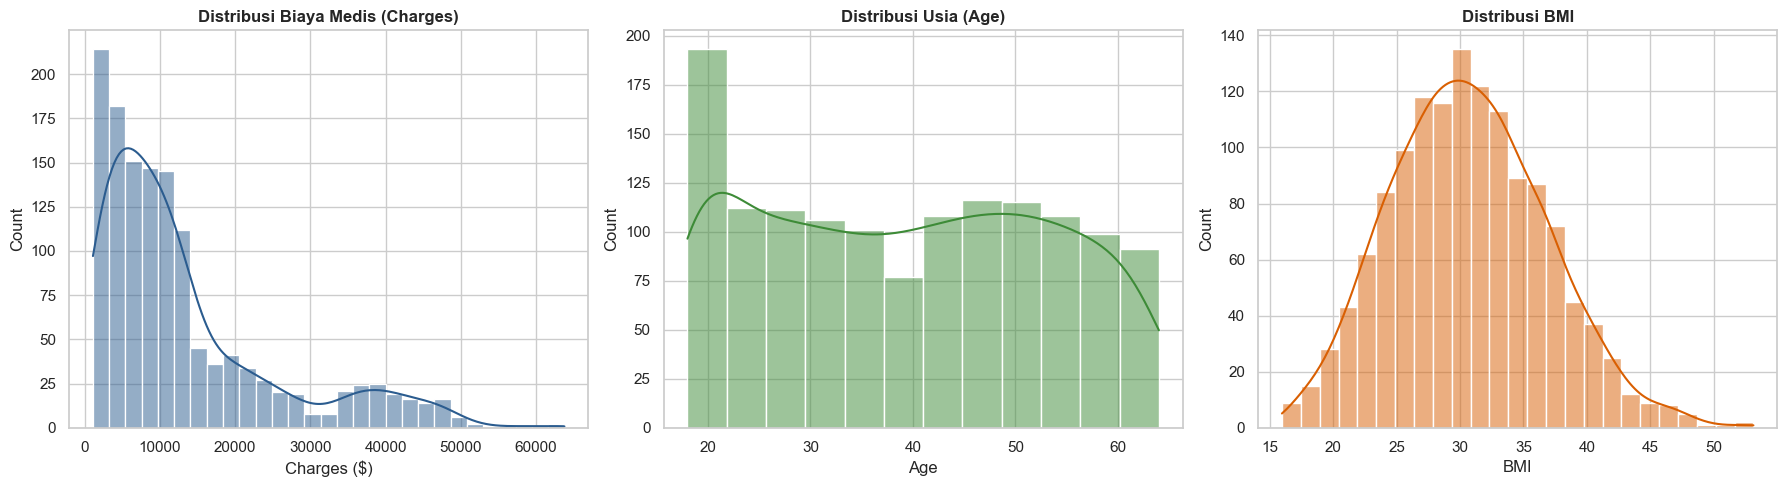

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["charges"], kde=True, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Distribusi Biaya Medis (Charges)", fontweight="bold")
axes[0].set_xlabel("Charges ($)")

sns.histplot(df["age"], kde=True, ax=axes[1], color="#3d8b37")
axes[1].set_title("Distribusi Usia (Age)", fontweight="bold")
axes[1].set_xlabel("Age")

sns.histplot(df["bmi"], kde=True, ax=axes[2], color="#d95f02")
axes[2].set_title("Distribusi BMI", fontweight="bold")
axes[2].set_xlabel("BMI")

plt.tight_layout()
plt.show()

C:\Users\RHESA\AppData\Local\Temp\ipykernel_25980\3441359167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="smoker", palette="Set2", ax=axes[0])
C:\Users\RHESA\AppData\Local\Temp\ipykernel_25980\3441359167.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex", palette="Set1", ax=axes[1])
C:\Users\RHESA\AppData\Local\Temp\ipykernel_25980\3441359167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region", palette="Pastel1", ax=axes[2])


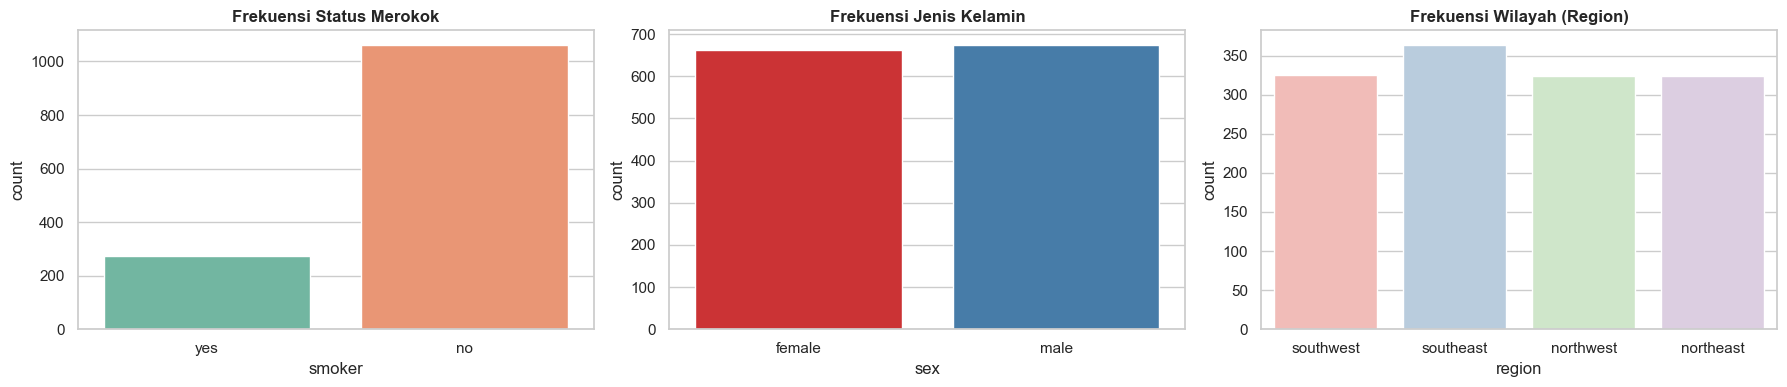

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="smoker", palette="Set2", ax=axes[0])
axes[0].set_title("Frekuensi Status Merokok", fontweight="bold")

sns.countplot(data=df, x="sex", palette="Set1", ax=axes[1])
axes[1].set_title("Frekuensi Jenis Kelamin", fontweight="bold")

sns.countplot(data=df, x="region", palette="Pastel1", ax=axes[2])
axes[2].set_title("Frekuensi Wilayah (Region)", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.3 Analisis Bivariat & Multivariat
Hubungan antara prediktor utama terhadap biaya medis tahunan (`charges`).

C:\Users\RHESA\AppData\Local\Temp\ipykernel_25980\4055846330.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="charges", palette=palette, ax=axes[2])


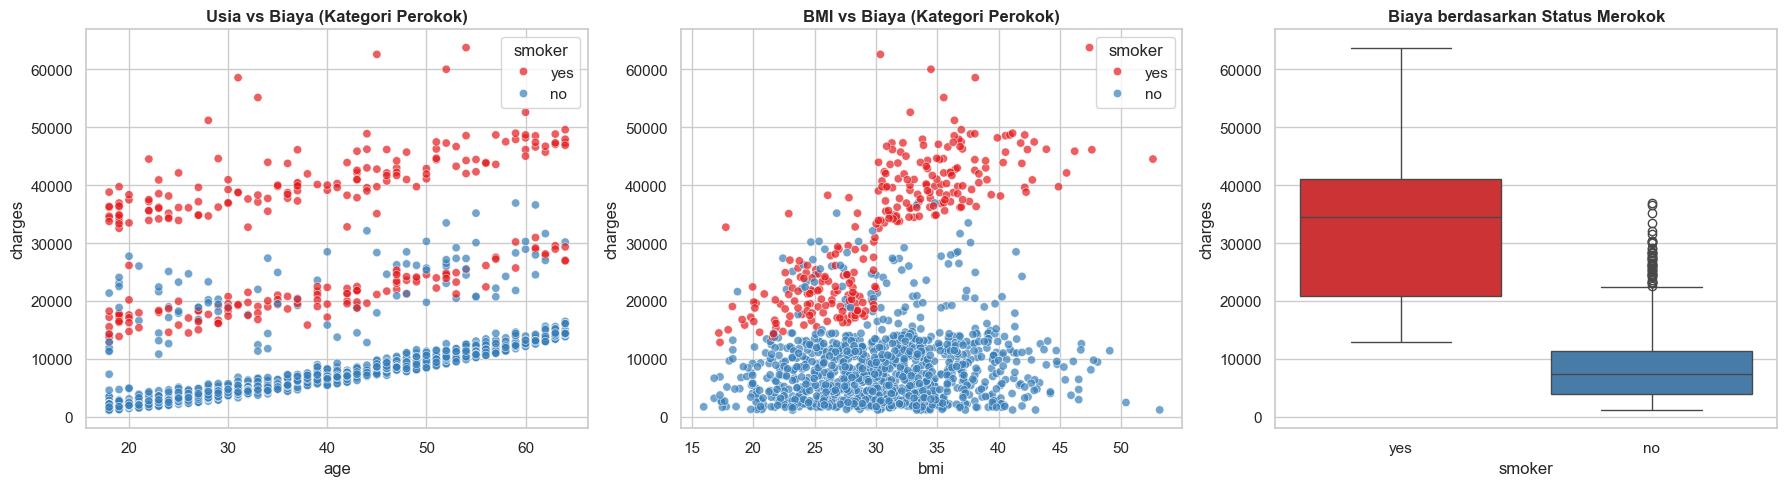

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {"yes": "#e41a1c", "no": "#377eb8"}

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", palette=palette, alpha=0.7, ax=axes[0])
axes[0].set_title("Usia vs Biaya (Kategori Perokok)", fontweight="bold")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette=palette, alpha=0.7, ax=axes[1])
axes[1].set_title("BMI vs Biaya (Kategori Perokok)", fontweight="bold")

sns.boxplot(data=df, x="smoker", y="charges", palette=palette, ax=axes[2])
axes[2].set_title("Biaya berdasarkan Status Merokok", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.4 Matriks Korelasi
Korelasi linear antar prediktor dan variabel target.

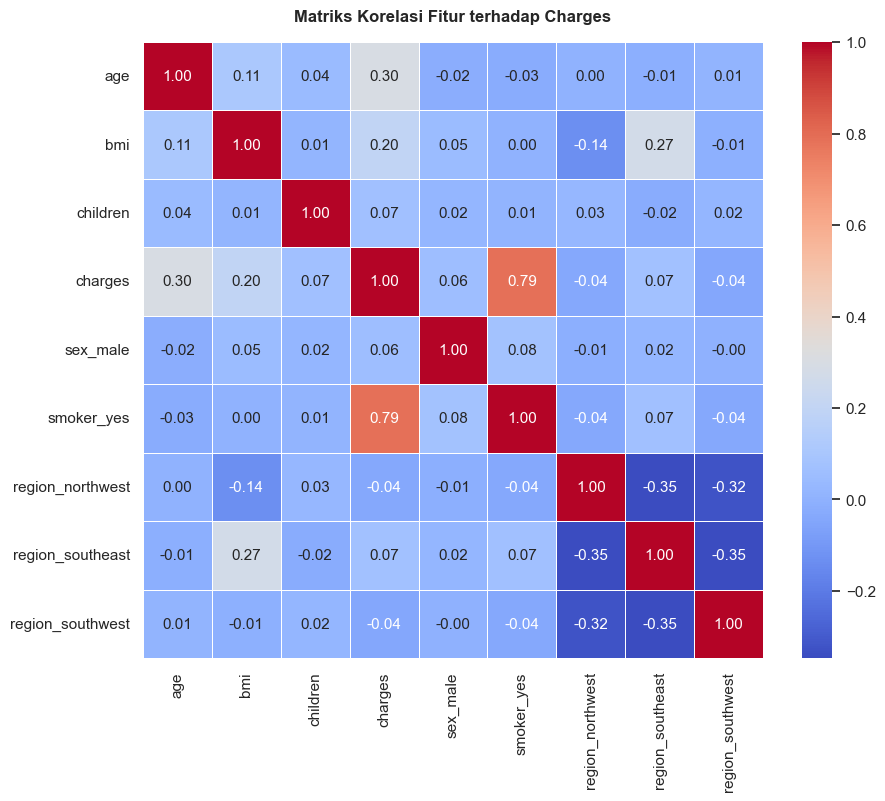

In [10]:
df_encoded_temp = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True, dtype=int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded_temp.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur terhadap Charges", fontweight="bold", pad=15)
plt.show()

### 5.5 Analisis Pencilan (Outliers)
Deteksi pencilan pada variabel target menggunakan metode rentang interkuartil (IQR).

In [11]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df["charges"] < lower_bound) | (df["charges"] > upper_bound)).sum()
print(f"IQR: {IQR:.2f} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers detected: {outliers_count} ({outliers_count / len(df) * 100:.2f}%)")

IQR: 11911.37 | Bounds: [-13120.72, 34524.78]
Outliers detected: 139 (10.40%)


## 6. Data Preparation

Tahapan data preparation yang dilakukan:
1. **One-Hot Encoding**: Mengonversi variabel kategorikal (`sex`, `smoker`, `region`) menjadi variabel dummy numerik dengan `drop_first=True`.
2. **Train-Test Split**: Membagi dataset dengan rasio 80:20 (`random_state=42`).
3. **Feature Scaling (StandardScaler)**: Menstandarisasi fitur numerik (`age`, `bmi`, `children`) berdasarkan parameter statistik data latih.

In [12]:
df_prep = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True, dtype=int)
df_prep.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [13]:
X = df_prep.drop(columns=["charges"])
y = df_prep["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (1069, 8), X_test: (268, 8)


In [14]:
num_features = ["age", "bmi", "children"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

X_train_scaled.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1113,-1.157680,-0.996928,-0.907908,1,0,0,0,0
967,-1.300619,-0.792762,0.766904,1,0,0,0,0
598,0.914926,1.154664,0.766904,0,0,1,0,0
170,1.701087,1.806837,-0.907908,1,0,0,1,0
275,0.557580,-0.651417,0.766904,0,0,0,0,0


## 7. Modeling

Tiga algoritma regresi baseline yang diuji:
1. **K-Nearest Neighbors (KNN) Regressor** (`n_neighbors=5`)
2. **Random Forest Regressor** (`n_estimators=100, max_depth=16`)
3. **Gradient Boosting Regressor** (`n_estimators=100, learning_rate=0.1, max_depth=3`)

In [15]:
models = {
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, y_tr_pred),
        "Test MSE": mean_squared_error(y_test, y_te_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_tr_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_te_pred)),
        "Train MAE": mean_absolute_error(y_train, y_tr_pred),
        "Test MAE": mean_absolute_error(y_test, y_te_pred),
        "Train R2": r2_score(y_train, y_tr_pred),
        "Test R2": r2_score(y_test, y_te_pred),
    })

pd.DataFrame(results)

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,KNN,2.802474e+07,6.500415e+07,5293.839364,8062.515078,3125.864067,4494.192816,0.795312,0.646248
1,Random Forest,3.592596e+06,2.223877e+07,1895.414370,4715.799865,1057.308085,2646.950940,0.973760,0.878977
2,Gradient Boosting,1.484109e+07,1.821824e+07,3852.413107,4268.283018,2109.395469,2517.467831,0.891603,0.900856


### 7.1 Hyperparameter Tuning
Optimasi hyperparameter Gradient Boosting menggunakan `GridSearchCV` dengan 5-fold cross-validation.

In [16]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)
best_gb = grid_search.best_estimator_

grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}

In [17]:
y_tr_pred_best = best_gb.predict(X_train_scaled)
y_te_pred_best = best_gb.predict(X_test_scaled)

results.append({
    "Model": "Gradient Boosting (Tuned)",
    "Train MSE": mean_squared_error(y_train, y_tr_pred_best),
    "Test MSE": mean_squared_error(y_test, y_te_pred_best),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_tr_pred_best)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_te_pred_best)),
    "Train MAE": mean_absolute_error(y_train, y_tr_pred_best),
    "Test MAE": mean_absolute_error(y_test, y_te_pred_best),
    "Train R2": r2_score(y_train, y_tr_pred_best),
    "Test R2": r2_score(y_test, y_te_pred_best),
})

eval_df = pd.DataFrame(results)
eval_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,KNN,2.802474e+07,6.500415e+07,5293.839364,8062.515078,3125.864067,4494.192816,0.795312,0.646248
1,Random Forest,3.592596e+06,2.223877e+07,1895.414370,4715.799865,1057.308085,2646.950940,0.973760,0.878977
2,Gradient Boosting,1.484109e+07,1.821824e+07,3852.413107,4268.283018,2109.395469,2517.467831,0.891603,0.900856
3,Gradient Boosting (Tuned),1.828280e+07,1.816081e+07,4275.838573,4261.550418,2418.138740,2526.738615,0.866466,0.901169


## 8. Model Evaluation

### 8.1 Metrik Evaluasi
- **MSE (Mean Squared Error)**: Rata-rata kuadrat selisih antara nilai aktual dan prediksi.
- **RMSE (Root Mean Squared Error)**: Akar dari MSE, memiliki interpretasi unit yang sama dengan variabel target ($).
- **MAE (Mean Absolute Error)**: Rata-rata selisih absolut antara nilai aktual dan prediksi.
- **$R^2$ (R-Squared)**: Proporsi varians variabel target yang mampu dijelaskan oleh model.

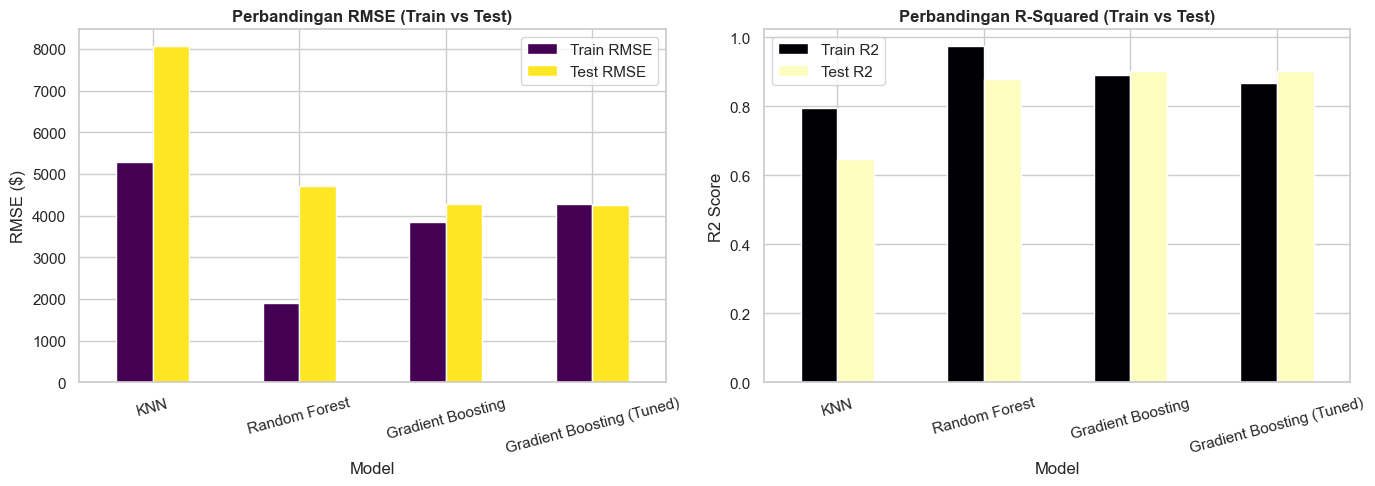

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eval_df.plot(x="Model", y=["Train RMSE", "Test RMSE"], kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("Perbandingan RMSE (Train vs Test)", fontweight="bold")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_xticklabels(eval_df["Model"], rotation=15)

eval_df.plot(x="Model", y=["Train R2", "Test R2"], kind="bar", ax=axes[1], colormap="magma")
axes[1].set_title("Perbandingan R-Squared (Train vs Test)", fontweight="bold")
axes[1].set_ylabel("R2 Score")
axes[1].set_xticklabels(eval_df["Model"], rotation=15)

plt.tight_layout()
plt.show()

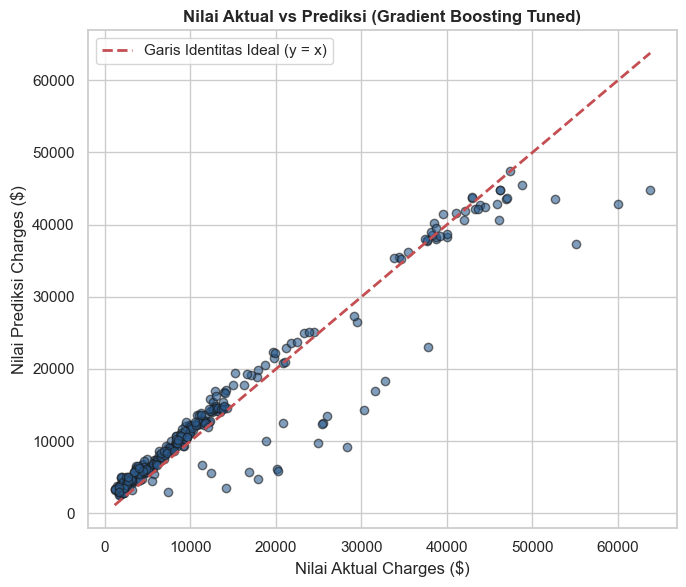

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_te_pred_best, alpha=0.6, color="#2b5c8f", edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Garis Identitas Ideal (y = x)")
plt.title("Nilai Aktual vs Prediksi (Gradient Boosting Tuned)", fontweight="bold")
plt.xlabel("Nilai Aktual Charges ($)")
plt.ylabel("Nilai Prediksi Charges ($)")
plt.legend()
plt.tight_layout()
plt.show()

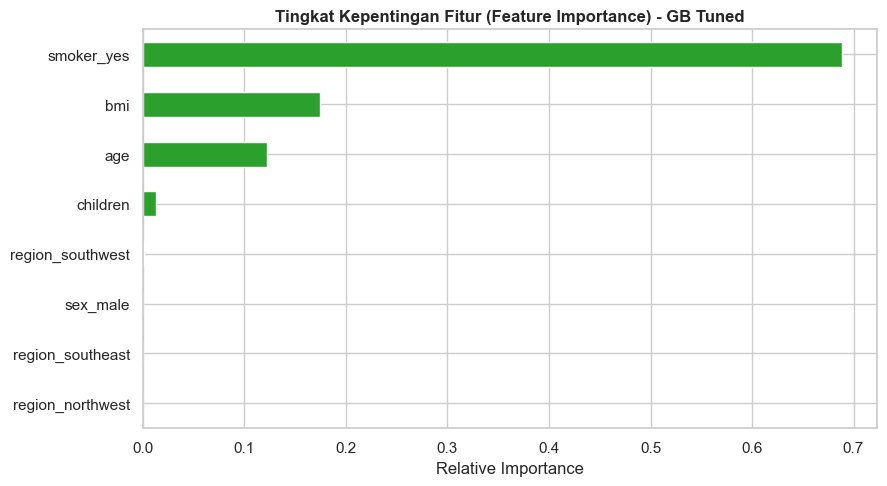

In [20]:
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind="barh", color="#2ca02c")
plt.title("Tingkat Kepentingan Fitur (Feature Importance) - GB Tuned", fontweight="bold")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

## 9. Kesimpulan dan Dampak Bisnis

1. **Model Terbaik:** Model **Gradient Boosting Regressor (Tuned)** menghasilkan performa terbaik dengan **Test ^2$ = 0.901169** dan **Test RMSE = ,261.55**, menunjukkan stabilitas generalisasi optimal (*best fit*) tanpa gejala overfitting.
2. **Faktor Dominan:** Status merokok (smoker_yes) terbukti sebagai prediktor utama (>60% relative importance), yang berinteraksi kuat dengan kategori BMI obesitas dan faktor usia dalam melipatgandakan klaim medis.
3. **Pencapaian Goals & Dampak Bisnis:** Target akurasi proyek (^2 > 0.85$) berhasil dilampaui. Model ini memungkinkan perusahaan asuransi menerapkan penaksiran premi berbasis profil risiko nyata (*risk-based pricing*), memitigasi potensi defisit akibat *underpricing*, serta mencegah *adverse selection*.